In [1]:
import os
import numpy as np
import pandas as pd
import sys
import json
import networkx as nx
import matplotlib.pyplot as plt
import math
from glob import glob
import os.path as op

# Add rpy2
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2EEBEE81-EBFD-3117-97B1-20AFEEB66792> /Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [31]:
%%R 

suppressPackageStartupMessages({
    library(broom)
    library(cowplot)
    library(ggpubr)
    library(ggsignif)
    library(ggforce)
    library(ggVennDiagram)
    library(glue)
    library(patchwork)
    library(rlist)
    library(see)
    library(tidyverse)
})


# Set cowplot theme
theme_set(theme_cowplot())

In [3]:
# Define base_repo as one level up from current directory
base_repo = op.dirname(op.abspath(''))
plot_dir = f"{base_repo}/data_visualization/plots/"
data_dir = "/Users/abry4213/data/MEG_functional_connectivity/derivatives/classification_results/across_participants/"

In [28]:
logistic_regression_results = pd.read_csv(f"{data_dir}/comparing_between_stimulus_types_Logistic_Regression_classification_results_AUC.csv")
linear_SVM_results = pd.read_csv(f"{data_dir}/comparing_between_stimulus_types_Linear_SVM_classification_results_AUC.csv")
rbf_results = pd.read_csv(f"{data_dir}/comparing_between_stimulus_types_RBF_SVM_classification_results_AUC.csv")

all_results_accuracy = (pd.concat([logistic_regression_results, linear_SVM_results, rbf_results], axis=0)
                        # Long to wide format, names from Model and values from accuracy
                        .pivot(index=['SPI', 'meta_ROI_from', 'meta_ROI_to', 'relevance_type', 'stimulus_presentation', 'stimulus_combo'], columns='classifier', values='accuracy')
                        .reset_index()
)

all_results_accuracy.head()

classifier,SPI,meta_ROI_from,meta_ROI_to,relevance_type,stimulus_presentation,stimulus_combo,Linear_SVM,Logistic_Regression,RBF_SVM
0,anm,Category_Selective,IPS,Irrelevant,off,"('face', 'letter')",0.512778,0.500000,0.506667
1,anm,Category_Selective,IPS,Irrelevant,off,"('face', 'object')",0.515000,0.510556,0.540556
2,anm,Category_Selective,IPS,Irrelevant,off,"('false', 'face')",0.506111,0.500000,0.480000
3,anm,Category_Selective,IPS,Irrelevant,off,"('false', 'letter')",0.414444,0.500000,0.408889
4,anm,Category_Selective,IPS,Irrelevant,off,"('false', 'object')",0.453889,0.494444,0.492778


## Comparing classifier types

`geom_smooth()` using formula = 'y ~ x'


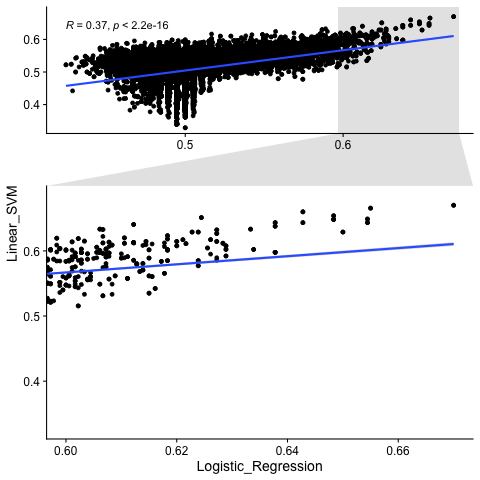

In [42]:
%%R -i all_results_accuracy 

all_results_accuracy %>% 
    ggplot(data=., mapping=aes(x=Logistic_Regression, y=Linear_SVM)) +
    geom_point()  +
    facet_zoom(x = Logistic_Regression >= 0.60) +
    geom_smooth(method='lm') +
    stat_cor(method = "pearson")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


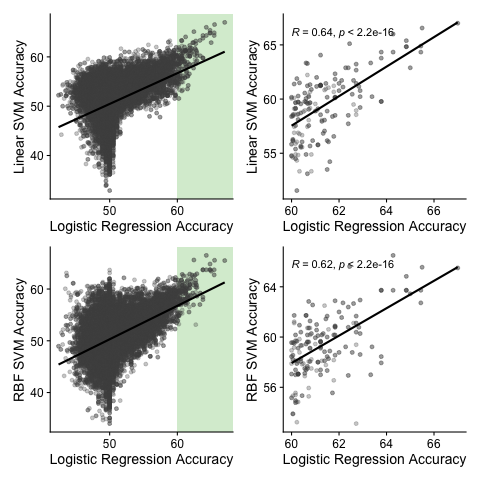

In [62]:
%%R -i all_results_accuracy,plot_dir

rect_df = data.frame(
    Logistic_Regression = 0.6,
    Linear_SVM = 0.6,
    RBF_SVM = 0.6
)

all_Linear_plot <- all_results_accuracy %>% 
    ggplot(data=., mapping=aes(x=Logistic_Regression*100, y=Linear_SVM*100)) +
    geom_rect(data=rect_df, xmin=60, xmax=Inf, ymin=-Inf, ymax=Inf, fill="#B0DBA8", alpha=0.5) +
    ylab("Linear SVM Accuracy") +
    xlab("Logistic Regression Accuracy") +
    geom_point(color='gray30', alpha=0.3)  +
    geom_smooth(method='lm', se=F, color='black')

all_RBF_plot <- all_results_accuracy %>% 
    ggplot(data=., mapping=aes(x=Logistic_Regression*100, y=RBF_SVM*100)) +
    geom_rect(data=rect_df, xmin=60, xmax=Inf, ymin=-Inf, ymax=Inf, fill="#B0DBA8", alpha=0.5) +
    ylab("RBF SVM Accuracy") +
    xlab("Logistic Regression Accuracy") +
    geom_point(color='gray30', alpha=0.3)  +
    geom_smooth(method='lm', se=F, color='black')

above_Linear_60_plot <- all_results_accuracy %>% 
    filter(Logistic_Regression >= 0.6) %>%
    ggplot(data=., mapping=aes(x=Logistic_Regression*100, y=Linear_SVM*100)) +
    ylab("Linear SVM Accuracy") +
    xlab("Logistic Regression Accuracy") +
    stat_cor(method = "pearson") +
    geom_point(color='gray30', alpha=0.3)  +
    geom_smooth(method='lm', se=F, color='black')

above_RBF_60_plot <- all_results_accuracy %>%
    filter(Logistic_Regression >= 0.6) %>%
    ggplot(data=., mapping=aes(x=Logistic_Regression*100, y=RBF_SVM*100)) +
    ylab("RBF SVM Accuracy") +
    xlab("Logistic Regression Accuracy") +
    stat_cor(method = "pearson") +
    geom_point(color='gray30', alpha=0.3)  +
    geom_smooth(method='lm', se=F, color='black')

wrap_plots(list(all_Linear_plot, above_Linear_60_plot, all_RBF_plot, above_RBF_60_plot), ncol=2)
# ggsave(glue("{plot_dir}/inter_subject_classification/Model_type_accuracy_comparisons.svg"), width=8, height=8, units='in', dpi=300)

## Accuracy vs. AUC

In [66]:
logistic_regression_results.head()

,SPI,classifier,meta_ROI_from,meta_ROI_to,relevance_type,stimulus_presentation,stimulus_combo,accuracy,accuracy_SD,AUC,AUC_SD
0,cov_EmpiricalCovariance,Logistic_Regression,Category_Selective,IPS,Relevant-non-target,on,"('false', 'face')",0.602778,0.075164,0.654000,0.104137
1,cov_EmpiricalCovariance,Logistic_Regression,Category_Selective,IPS,Relevant-non-target,on,"('false', 'letter')",0.500000,0.000000,0.500000,0.000000
2,cov_EmpiricalCovariance,Logistic_Regression,Category_Selective,IPS,Relevant-non-target,on,"('false', 'object')",0.483333,0.050000,0.529321,0.068504
3,cov_EmpiricalCovariance,Logistic_Regression,Category_Selective,IPS,Relevant-non-target,on,"('face', 'letter')",0.612222,0.101890,0.604716,0.112588
4,cov_EmpiricalCovariance,Logistic_Regression,Category_Selective,IPS,Relevant-non-target,on,"('face', 'object')",0.595000,0.055581,0.580259,0.094867


In [92]:
%%R -i logistic_regression_results

logistic_regression_results %>% 
    ggplot(data=., mapping=aes(x=accuracy*100, y=AUC)) +
    # stat_cor(method = "pearson") +
    geom_point(alpha=0.3, mapping=aes(color=accuracy*100))  +
    ylab("CV-AUC from Logistic Regression ROC Curve") +
    xlab("CV-Accuracy from Logistic Regression") +
    ggtitle("Logistic regression accuracy vs. AUC\nacross all classification problems") +
    geom_smooth(method='lm', se=F, color='black') +
    scale_color_viridis_c(option='plasma', direction=-1) +
    theme(legend.position='none',
          plot.title = element_text(size=18, hjust=0.5),
          axis.title = element_text(size=16),
          axis.text = element_text(size=14))

ggsave(glue("{plot_dir}/inter_subject_classification/Logistic_regression_accuracy_vs_AUC.svg"), width=5, height=5, units='in', dpi=300)

`geom_smooth()` using formula = 'y ~ x'
